In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import tenseal as ts

Classes : ['AbdomenCT', 'BreastMRI', 'ChestCT']
Epoch 1/5 | Loss: 1.0260 | Acc: 0.3269
Epoch 2/5 | Loss: 0.9056 | Acc: 0.4099
Epoch 3/5 | Loss: 0.8052 | Acc: 0.6230
Epoch 4/5 | Loss: 0.7238 | Acc: 0.6506
Epoch 5/5 | Loss: 0.6580 | Acc: 0.6547


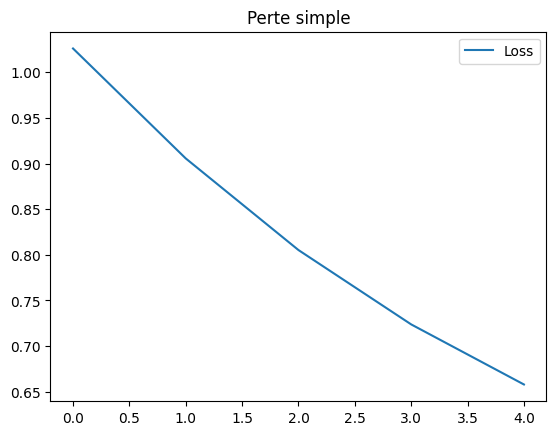

Poids exportés vers params_client2.txt


In [8]:


# --- Config minimale ---
data_dir = "data_hopital2"
image_size = 64
batch_size = 32
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Transformations simples ---
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# --- Dataset complet (pas de split ici) ---
dataset = datasets.ImageFolder(data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
class_names = dataset.classes
print("Classes :", class_names)

# --- CNN ultra-simple ---
class TinyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 4, kernel_size=3, padding=1),  # juste 4 filtres
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # sortie 4x1x1
            nn.Flatten(),
            nn.Linear(4, num_classes)  # directement la sortie
        )

    def forward(self, x):
        return self.model(x)

model = TinyCNN(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# --- Entraînement rapide ---
losses = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    acc = correct / total
    avg_loss = running_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")

# --- Courbe de perte ---
plt.plot(losses, label="Loss")
plt.title("Perte simple")
plt.legend()
plt.show()
def export_weights_to_txt(model, path="params_client2.txt"):
    with open(path, "w") as f:
        for name, param in model.named_parameters():
            f.write(f"{name}\n")
            f.write(" ".join(map(str, param.detach().cpu().numpy().flatten())))
            f.write("\n\n")
    print(f"Poids exportés vers {path}")

export_weights_to_txt(model, "params_client2.txt")


In [9]:
import tenseal as ts
import base64

PLAINTEXT_FILE = "params_client2.txt"  # adapter pour client2
CONTEXT_FILE = "context/key_private.txt"
OUTPUT_FILE = "client2/enc_model_client2.txt"

# Charger le contexte privé
with open(CONTEXT_FILE, "r") as f:
    context = ts.context_from(base64.b64decode(f.read()))

def load_plain_model(path):
    model = {}
    with open(path, "r") as f:
        lines = [l.strip() for l in f if l.strip()]
    for i in range(0, len(lines), 2):
        model[lines[i]] = list(map(float, lines[i + 1].split()))
    return model

def encrypt_model(model):
    encrypted = {}
    for key, values in model.items():
        vec = ts.ckks_vector(context, values)
        encrypted[key] = base64.b64encode(vec.serialize()).decode()
    return encrypted


def save_encrypted_model(model, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)  # <- crée le dossier si nécessaire
    with open(path, "w") as f:
        for key, vec_b64 in model.items():
            f.write(f"{key}\n{vec_b64}\n\n")


model = load_plain_model(PLAINTEXT_FILE)
encrypted = encrypt_model(model)
save_encrypted_model(encrypted, OUTPUT_FILE)

print("✅ Modèle chiffré sauvegardé en texte (Base64) dans", OUTPUT_FILE)




✅ Modèle chiffré sauvegardé en texte (Base64) dans client2/enc_model_client2.txt


In [ ]:
import os
import tenseal as ts
import base64

ENC_AVG_FILE = "server/enc_avg.txt"
CONTEXT_FILE = "context/key_private.txt"
DECRYPTED_AVG = "client2/decrypted_avg.txt"

with open(CONTEXT_FILE, "r") as f:
    context = ts.context_from(base64.b64decode(f.read()))

def load_encrypted_model(filepath):
    model = {}
    with open(filepath, "r") as f:
        lines = [l.strip() for l in f if l.strip()]
    for i in range(0, len(lines), 2):
        key = lines[i]
        vec = ts.ckks_vector_from(context, base64.b64decode(lines[i + 1]))
        model[key] = vec
    return model

def decrypt_and_save(model, out_path):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w") as out:
        for key, vec in model.items():
            vals = vec.decrypt()
            out.write(f"{key}\n{' '.join(f'{v:.6f}' for v in vals)}\n\n")
    print("✅ Résultat déchiffré sauvegardé dans", out_path)

if os.path.exists(ENC_AVG_FILE):
    print("🔓 Déchiffrement de la moyenne reçue...")
    avg_model = load_encrypted_model(ENC_AVG_FILE)
    decrypt_and_save(avg_model, DECRYPTED_AVG)
else:
    print(f"❌ Fichier {ENC_AVG_FILE} introuvable. Avez-vous bien exécuté le serveur ?")


🔓 Déchiffrement de la moyenne reçue...
✅ Résultat déchiffré sauvegardé dans client2/decrypted_avg.txt
